# Multi-Class Network Intrusion Detection using GCN-BiGRU
This notebook presents an end-to-end multi-class classification pipeline for the CICIDS2017 dataset. We process the raw dataset and train a Graph Convolutional Network (GCN) combined with a Bidirectional Gated Recurrent Unit (BiGRU) to identify various types of network intrusions.

**Key stages:**
1. **Imports & Configuration**: Environment, GPU configuration, and hyperparameters.
2. **Data Loading**: Loading the CICIDS2017 dataset.
3. **Data Preprocessing & Balancing**: Label encoding, feature selection (`VarianceThreshold`), scaling, and addressing class imbalance (`SMOTE`).
4. **Model Architecture Definition**: Defining the `SimpleGCN` and the BiGRU network.
5. **Training Pipeline**: Custom training loops and loss formulations.
6. **Evaluation**: Metrics reporting (Accuracy, F1-scores) and confusion matrix visualization.

## 1. Imports & Configuration
Set up the python environment, import necessary libraries, and verify that the CUDA GPU is available for TensorFlow.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

# TensorFlow setup
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

if os.name == 'nt':
    lib_bin = os.path.join(sys.prefix, 'Library', 'bin')
    if os.path.isdir(lib_bin):
        try:
            os.add_dll_directory(lib_bin)
        except AttributeError:
            pass
        os.environ['PATH'] = lib_bin + os.pathsep + os.environ.get('PATH', '')

import tensorflow as tf

# CRITICAL FIX: Configure GPU memory growth to prevent allocation errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('✓ GPU memory growth enabled (dynamic allocation)')
    except RuntimeError as e:
        print(f'⚠️  Could not set GPU memory growth: {e}')

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization, Bidirectional, Input, Layer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Configuration Variables
DATA_PATH = './dataset/cicids2017/cicids2017_cleaned.csv'
LABEL_COL = 'Attack Type'
SEED = 42
EPOCHS = 100
BATCH_SIZE = 1024

np.random.seed(SEED)
tf.random.set_seed(SEED)

def _gpu_status():
    """Prints the status of available GPUs for TensorFlow."""
    tf_gpus = tf.config.list_physical_devices('GPU')
    print(f'TensorFlow version: {tf.__version__}')
    print(f'Visible GPUs      : {len(tf_gpus)}')
    if tf_gpus:
        for gpu in tf_gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f'GPU ready         : {gpu.name} (memory growth enabled)')
        print('Status            : CUDA is active in this kernel.')
    else:
        print('Status            : CUDA is not active. Expect slow training.')

_gpu_status()

# Plotting config
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

✓ GPU memory growth enabled (dynamic allocation)
TensorFlow version: 2.10.1
Visible GPUs      : 1
GPU ready         : /physical_device:GPU:0 (memory growth enabled)
Status            : CUDA is active in this kernel.


## 2. Data Loading
Load the raw dataset from CSV and create an initial train/test split.

In [2]:
# Load and trim
df_all = pd.read_csv(DATA_PATH)
df_all[LABEL_COL] = df_all[LABEL_COL].astype(str).str.strip()

# Build a held-out test split
df_train, df_test_raw = train_test_split(
    df_all, test_size=0.20, random_state=SEED, stratify=df_all[LABEL_COL]
)
df = df_train.copy()

print(f'Total data samples: {df_all.shape[0]}')
print(f'Training shape    : {df_train.shape}')
print(f'Test shape        : {df_test_raw.shape}')

df[LABEL_COL].value_counts()

Total data samples: 2520751
Training shape    : (2016600, 53)
Test shape        : (504151, 53)


Attack Type
Normal Traffic    1676045
DoS                154996
DDoS               102411
Port Scanning       72555
Brute Force          7320
Web Attacks          1714
Bots                 1559
Name: count, dtype: int64

## 3. Data Preprocessing & Feature Engineering
Prepare the classification targets (labels) and numeric features. This includes dropping invariant features using `VarianceThreshold` and preventing data leakage by fitting our scaler strictly to the training split.

In [3]:
# 3.1 — Multi-class Label Encoding
# We transform text-based attack categories into numeric integer classes (0 to NUM_CLASSES-1)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[LABEL_COL].astype(str).str.strip())
CLASS_NAMES = label_encoder.classes_.tolist()
NUM_CLASSES = len(CLASS_NAMES)

print('Multi-class label distribution:')
for cls_name, cls_idx in zip(CLASS_NAMES, range(NUM_CLASSES)):
    count = int((y == cls_idx).sum())
    pct = count / len(y) * 100
    print(f'  {cls_name:25s}: {count:>10,}  ({pct:.1f}%)')
print(f'Number of classes : {NUM_CLASSES}')

Multi-class label distribution:
  Bots                     :      1,559  (0.1%)
  Brute Force              :      7,320  (0.4%)
  DDoS                     :    102,411  (5.1%)
  DoS                      :    154,996  (7.7%)
  Normal Traffic           :  1,676,045  (83.1%)
  Port Scanning            :     72,555  (3.6%)
  Web Attacks              :      1,714  (0.1%)
Number of classes : 7


In [4]:
# 3.2 -- Build Feature Matrix
# Drop strictly identifier/label columns to isolate input features
DROP = [LABEL_COL, 'class_idx', 'binary_label', 'id', 'label']
DROP = [c for c in DROP if c in df.columns]

X_raw = df.drop(columns=DROP).select_dtypes(include=[np.number])

# Feature Selection: Remove constant or near-constant features using VarianceThreshold.
# VarianceThreshold(1e-4) removes any feature where > ~99% of samples have the same value.
# This prevents dead weights in the network and speeds up training.
vt = VarianceThreshold(threshold=1e-4)
X_vt = vt.fit_transform(X_raw)
SELECTED_FEATURES = X_raw.columns[vt.get_support()].tolist()

X = pd.DataFrame(X_vt, columns=SELECTED_FEATURES)
NUM_FEATURES = X.shape[1]

print(f'Feature matrix: {X.shape[0]:,} samples x {NUM_FEATURES} active features')

Feature matrix: 2,016,600 samples x 52 active features


In [5]:
# 3.3 -- Train / Validation / Test Split
# We stratify all splits relative to the minority class label to maintain exact representations
# Train & Validation (85/15)

y_test_labels = df_test_raw[LABEL_COL].astype(str).str.strip()
y_test = label_encoder.transform(y_test_labels)

# Extract raw test datamatrix
DROP_test = [LABEL_COL, 'class_idx', 'binary_label', 'id', 'label']
DROP_test = [c for c in DROP_test if c in df_test_raw.columns]
X_test_raw = df_test_raw.drop(columns=DROP_test).select_dtypes(include=[np.number])

# Clean the test matrix: Align with selected features and clip Infinities to medians
X_test_raw = X_test_raw.replace([np.inf, -np.inf], np.nan)
X_test_raw = X_test_raw[SELECTED_FEATURES].fillna(X.median())

# Extract arrays
X_arr = X.values
y_type_arr = df[LABEL_COL].astype(str).values

# Generate Final Inner Split (Val test_size=0.15)
X_train, X_val, y_train, y_val, y_type_train, y_type_val = train_test_split(
    X_arr, y, y_type_arr, test_size=0.15, random_state=SEED, stratify=y
)
X_test = X_test_raw.values

print('Train class distribution:')
for cls_name, cls_idx in zip(CLASS_NAMES, range(NUM_CLASSES)):
    print(f'  {cls_name:25s}: {(y_train==cls_idx).sum():,}')
print('Validation class distribution:')
for cls_name, cls_idx in zip(CLASS_NAMES, range(NUM_CLASSES)):
    print(f'  {cls_name:25s}: {(y_val==cls_idx).sum():,}')
print('Test class distribution:')
for cls_name, cls_idx in zip(CLASS_NAMES, range(NUM_CLASSES)):
    print(f'  {cls_name:25s}: {(y_test==cls_idx).sum():,}')

Train class distribution:
  Bots                     : 1,325
  Brute Force              : 6,222
  DDoS                     : 87,049
  DoS                      : 131,747
  Normal Traffic           : 1,424,638
  Port Scanning            : 61,672
  Web Attacks              : 1,457
Validation class distribution:
  Bots                     : 234
  Brute Force              : 1,098
  DDoS                     : 15,362
  DoS                      : 23,249
  Normal Traffic           : 251,407
  Port Scanning            : 10,883
  Web Attacks              : 257
Test class distribution:
  Bots                     : 389
  Brute Force              : 1,830
  DDoS                     : 25,603
  DoS                      : 38,749
  Normal Traffic           : 419,012
  Port Scanning            : 18,139
  Web Attacks              : 429


In [6]:
# 3.4 — Standardization
# Apply zero-mean and unit variance to input coordinates. 
# Crucially: `fit` strictly on X_train only to prevent test-set distribution leakage.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f'Scaled Data — Train mean: {X_train.mean():.4f} | Std: {X_train.std():.4f}')



Scaled Data — Train mean: 0.0000 | Std: 1.0000


In [7]:
# 3.5 — Memory & GPU Diagnostics
print('\n' + '='*60)
print('MEMORY & GPU DIAGNOSTICS')
print('='*60)

# Check GPU memory
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(f'GPU: {gpu}')
    # Show current GPU memory usage
    with tf.device('/GPU:0'):
        test_tensor = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        print(f'✓ GPU tensor test passed')
else:
    print('⚠️  No GPU detected - training will be slow')

# Estimate data size
print(f'\nData shape after scaling: {X_train.shape}')
print(f'Memory per sample: ~{X_train.nbytes / X_train.shape[0] / 1024:.1f} KB')
print(f'Total training data size: ~{X_train.nbytes / 1024 / 1024:.1f} MB')


MEMORY & GPU DIAGNOSTICS
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✓ GPU tensor test passed

Data shape after scaling: (1714110, 52)
Memory per sample: ~0.4 KB
Total training data size: ~680.0 MB


## 4. Model Architecture (GCN + BiGRU)
We construct a hybrid deep learning model:
- **SimpleGCN**: A standard 1-layer Graph Convolutional Network that detects non-linear feature-to-feature spatial relationships.
- **BiGRU**: A Bidirectional Gated Recurrent Unit layer optimized to process temporal packets and complex sequential attack patterns.

In [ ]:
print('PHASE 1 - Initial Training')
print('='*50)

TIMESTEPS = globals().get('TIMESTEPS', 1)

class SimpleGCN(tf.keras.layers.Layer):
    """
    A simplified custom Graph Convolutional Network (GCN) layer.
    
    This layer assumes that the normalized adjacency matrix defines the topological relationship 
    between different features. It maps the feature dimension into an alternative representation space.

    Args:
        units (int): The number of hidden neurons or feature mappings in the GCN layer.
        adjacency (np.ndarray): Target Adjacency matrix of shape (features, features). 
        activation (str): Activation function to apply (e.g., 'relu').
        l2_reg (float): The coefficient representing the depth of weight regularization.
    """
    def __init__(self, units, adjacency=None, activation='relu', l2_reg=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.l2_reg = l2_reg
        self.adjacency = None if adjacency is None else tf.constant(adjacency, dtype=tf.float32)

    def build(self, input_shape):
        """Initializes the trainable weight matrices."""
        in_dim = int(input_shape[-1])
        self.w = self.add_weight(shape=(in_dim, self.units), initializer='glorot_uniform',
                                 regularizer=tf.keras.regularizers.l2(self.l2_reg), trainable=True, name='gcn_w')
        self.b = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True, name='gcn_b')
        super().build(input_shape)

    def call(self, x):
        """Applies the Graph Convolution Transform."""
        if self.adjacency is None:
            xg = x
        else:
            xg = tf.einsum('btf,fg->btg', x, tf.cast(self.adjacency, x.dtype))
        out = tf.einsum('btf,fu->btu', xg, self.w) + self.b
        return self.activation(out)


def build_gcn_bigru(num_features, adjacency=None, timesteps=1, dropout=0.15, reg=1e-4):
    """
    Constructs the end-to-end multi-class Graph + RNN Network architecture.
    
    Returns:
       model (tf.keras.Model): Uncompiled keras architecture.
    """
    m = Sequential(name='GCN_BiGRU_Multiclass')
    m.add(Input(shape=(timesteps, num_features)))
    m.add(SimpleGCN(num_features, adjacency=adjacency, activation='relu', l2_reg=reg, name='gcn_front'))
    m.add(Bidirectional(GRU(128, return_sequences=True, kernel_regularizer=l2(reg), recurrent_regularizer=l2(reg))))
    m.add(BatchNormalization())
    m.add(Dropout(dropout))
    m.add(Bidirectional(GRU(64, return_sequences=False, kernel_regularizer=l2(reg))))
    m.add(BatchNormalization())
    m.add(Dropout(dropout))
    m.add(Dense(64, activation='relu', kernel_regularizer=l2(reg)))
    m.add(BatchNormalization())
    m.add(Dropout(dropout / 2))
    m.add(Dense(32, activation='relu'))
    m.add(Dropout(dropout / 4))
    m.add(Dense(NUM_CLASSES, activation='softmax', name='class_output'))
    return m

# ==========================================================
# 5. Training Pipeline (Optimized for 99% Accuracy & Recall)
# ==========================================================
if 'A_norm' not in globals():
    A_norm = np.eye(NUM_FEATURES, dtype=np.float32)

from collections import Counter
import math

# STRATEGY: Targeted SMOTE + Log-Smoothed Class Weights.
# Extreme class_weight='balanced' over-penalizes the majority classes (Normal Traffic).
# Instead, we boost extreme minorities to at least 50k samples, then apply logarithmic weights.
if 'X_train_bal' not in globals() or 'y_train_bal' not in globals() or 'class_weights_fit' not in globals():
    try:
        counts = Counter(y_train)
        # Raise minority classes to at least 50,000 samples to prevent ignoring them
        target_dict = {c: max(count, 50000) for c, count in counts.items()}
        
        print(f'Starting targeted SMOTE...')
        smote = SMOTE(sampling_strategy=target_dict, random_state=SEED, k_neighbors=3)
        X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        print(f'Applied SMOTE: {X_train.shape[0]:,} -> {X_train_bal.shape[0]:,} samples')
    except Exception as e:
        X_train_bal, y_train_bal = X_train.copy(), y_train.copy()
        print(f'SMOTE skipped ({e}); using unbalanced training data.')

    X_train_fit = X_train_bal
    y_train_fit = y_train_bal

    # Calculate log-smoothed class weights
    total = len(y_train_fit)
    classes_raw = np.unique(y_train_fit.astype(int))
    
    # log10(total / class_count) makes the weights scale gently instead of exponentially
    cw_raw = [math.log10(total / (float((y_train_fit == c).sum()))) for c in classes_raw]
    min_w = min(cw_raw)
    
    # Normalize giving the majority class a weight of ~1.0
    class_weights_fit = {int(c): float(w / min_w) for c, w in zip(classes_raw, cw_raw)}
    
    print('\nSmoothed Class Weights for Training:')
    for c, w in class_weights_fit.items():
        print(f'  {CLASS_NAMES[c]:25s}: {w:.3f}')
else:
    X_train_fit = X_train_bal
    y_train_fit = y_train_bal

X_train_lstm = X_train_fit.reshape(-1, TIMESTEPS, NUM_FEATURES)
if 'X_val_lstm' not in globals():
    X_val_lstm = X_val.reshape(-1, TIMESTEPS, NUM_FEATURES)
if 'X_test_lstm' not in globals():
    X_test_lstm = X_test.reshape(-1, TIMESTEPS, NUM_FEATURES)

print('\nPHASE 1 - Initial Training')
print('=' * 50)

policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)
print(f'Mixed precision policy: {policy.name}')

model = build_gcn_bigru(NUM_FEATURES, A_norm, TIMESTEPS)
model.compile(
    optimizer=Adam(learning_rate=8e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')]
)

cb1 = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(
        './dataset/cicids2017/best_phase1.weights.h5',
        monitor='val_accuracy', save_best_only=True, mode='max', save_weights_only=True, verbose=1
    ),
]

h1 = model.fit(
    X_train_lstm, y_train_fit,
    validation_data=(X_val_lstm, y_val),
    epochs=30,
    batch_size=256,
    class_weight=class_weights_fit,
    callbacks=cb1,
    verbose=1
)
print('\nPhase 1 complete!')

PHASE 1 - Initial Training
SMOTE config: k_neighbors=5, max_samples=500,000
Applied SMOTE + subsampling: 1,714,110 -> 500,000 samples

PHASE 1 - Initial Training
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU, compute capability 8.6
Mixed precision policy: mixed_float16
Epoch 1/25
3906/3907 [============================>.] - ETA: 0s - loss: 2.2590 - accuracy: 0.8555 - top3_acc: 0.9329
Epoch 1: val_accuracy improved from -inf to 0.59393, saving model to ./dataset/cicids2017\best_phase1.weights.h5
3907/3907 [==============================] - 95s 22ms/step - loss: 2.2588 - accuracy: 0.8555 - top3_acc: 0.9329 - val_loss: 2.3226 - val_accuracy: 0.5939 - val_top3_acc: 0.9040 - lr: 0.0010
Epoch 2/25
3904/3907 [============================>.] - ETA: 0s - loss: 0.9413 - accuracy: 0.9219 - top3_acc: 0.9853
Epoch 2

In [ ]:
print('PHASE 2 - Fine-Tuning')
print('='*50)

model = build_gcn_bigru(NUM_FEATURES, A_norm, TIMESTEPS)
model.load_weights('./dataset/cicids2017/best_phase1.weights.h5')
model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')]
)

cb2 = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4,
                      min_lr=1e-8, verbose=1),
    ModelCheckpoint('./dataset/cicids2017/best_finetuned.weights.h5',
                    monitor='val_accuracy', save_best_only=True, mode='max',
                    save_weights_only=True, verbose=1)
]

h2 = model.fit(
    X_train_lstm, y_train_fit,
    validation_data=(X_val_lstm, y_val),
    epochs=15,
    batch_size=128,
    class_weight=class_weights_fit,
    callbacks=cb2,
    verbose=1
)
print('\nPhase 2 complete!')

PHASE 2 - Fine-Tuning
Epoch 1/15
7813/7813 [==============================] - ETA: 0s - loss: 0.5139 - accuracy: 0.9687 - top3_acc: 0.9967
Epoch 1: val_accuracy improved from -inf to 0.89017, saving model to ./dataset/cicids2017\best_finetuned.weights.h5
7813/7813 [==============================] - 209s 26ms/step - loss: 0.5139 - accuracy: 0.9687 - top3_acc: 0.9967 - val_loss: 0.8142 - val_accuracy: 0.8902 - val_top3_acc: 0.9826 - lr: 5.0000e-05
Epoch 2/15
7811/7813 [============================>.] - ETA: 0s - loss: 0.5053 - accuracy: 0.9697 - top3_acc: 0.9970
Epoch 2: val_accuracy improved from 0.89017 to 0.89020, saving model to ./dataset/cicids2017\best_finetuned.weights.h5
7813/7813 [==============================] - 205s 26ms/step - loss: 0.5053 - accuracy: 0.9697 - top3_acc: 0.9970 - val_loss: 0.8075 - val_accuracy: 0.8902 - val_top3_acc: 0.9844 - lr: 5.0000e-05
Epoch 3/15
7813/7813 [==============================] - ETA: 0s - loss: 0.4963 - accuracy: 0.9703 - top3_acc: 0.9973
Ep

## 6. Evaluation
Final metric extraction on the completely unseen held-out test distribution. This includes calculating Top-1 accuracy, macro/weighted F1, and generating the normalized multi-class confusion matrix plot.

In [11]:
# GPU Memory Cleanup
print('\n' + '='*60)
print('CLEARING GPU MEMORY BEFORE EVALUATION')
print('='*60)

# Delete large training objects no longer needed
del model
import gc
gc.collect()

# Reset GPU memory
tf.keras.backend.clear_session()
print('GPU memory cleared and backend reset')
print('='*60)


CLEARING GPU MEMORY BEFORE EVALUATION
GPU memory cleared and backend reset


In [12]:
# 6.1 — Load best weights and predict on the test distributions
best_model = build_gcn_bigru(NUM_FEATURES, A_norm, TIMESTEPS)
best_model.load_weights('./dataset/cicids2017/best_finetuned.weights.h5')

# Predict class probabilities on validation and test sets
y_prob_val = best_model.predict(X_val_lstm, batch_size=512, verbose=0)
y_prob = best_model.predict(X_test_lstm, batch_size=512, verbose=0)

y_pred_val = np.argmax(y_prob_val, axis=1)
y_pred = np.argmax(y_prob, axis=1)

print('Multiclass prediction complete.')
print(f'Validation accuracy : {(y_pred_val == y_val).mean() * 100:.2f}%')
print(f'Test accuracy       : {(y_pred == y_test).mean() * 100:.2f}%')

Multiclass prediction complete.
Validation accuracy : 90.13%
Test accuracy       : 90.08%


In [13]:
# 6.2 — Comprehensive Metrics Profile
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print('=' * 60)
print('   GCN + BiGRU MULTI-CLASS IDS  —  TEST METRICS')
print('=' * 60)
print(f'  Accuracy    :  {acc * 100:.2f}%')
print(f'  Macro F1    :  {macro_f1 * 100:.2f}%')
print(f'  Weighted F1 :  {weighted_f1 * 100:.2f}%')
print()

# Detailed per-class precision, recall, f1-score report
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

   GCN + BiGRU MULTI-CLASS IDS  —  TEST METRICS
  Accuracy    :  90.08%
  Macro F1    :  57.70%
  Weighted F1 :  92.29%

                precision    recall  f1-score   support

          Bots     0.0309    0.9923    0.0599       389
   Brute Force     0.2047    0.9820    0.3388      1830
          DDoS     0.8024    0.9989    0.8899     25603
           DoS     0.7933    0.9843    0.8785     38749
Normal Traffic     1.0000    0.8823    0.9375    419012
 Port Scanning     0.7029    0.9988    0.8252     18139
   Web Attacks     0.0578    1.0000    0.1093       429

      accuracy                         0.9008    504151
     macro avg     0.5131    0.9769    0.5770    504151
  weighted avg     0.9589    0.9008    0.9229    504151



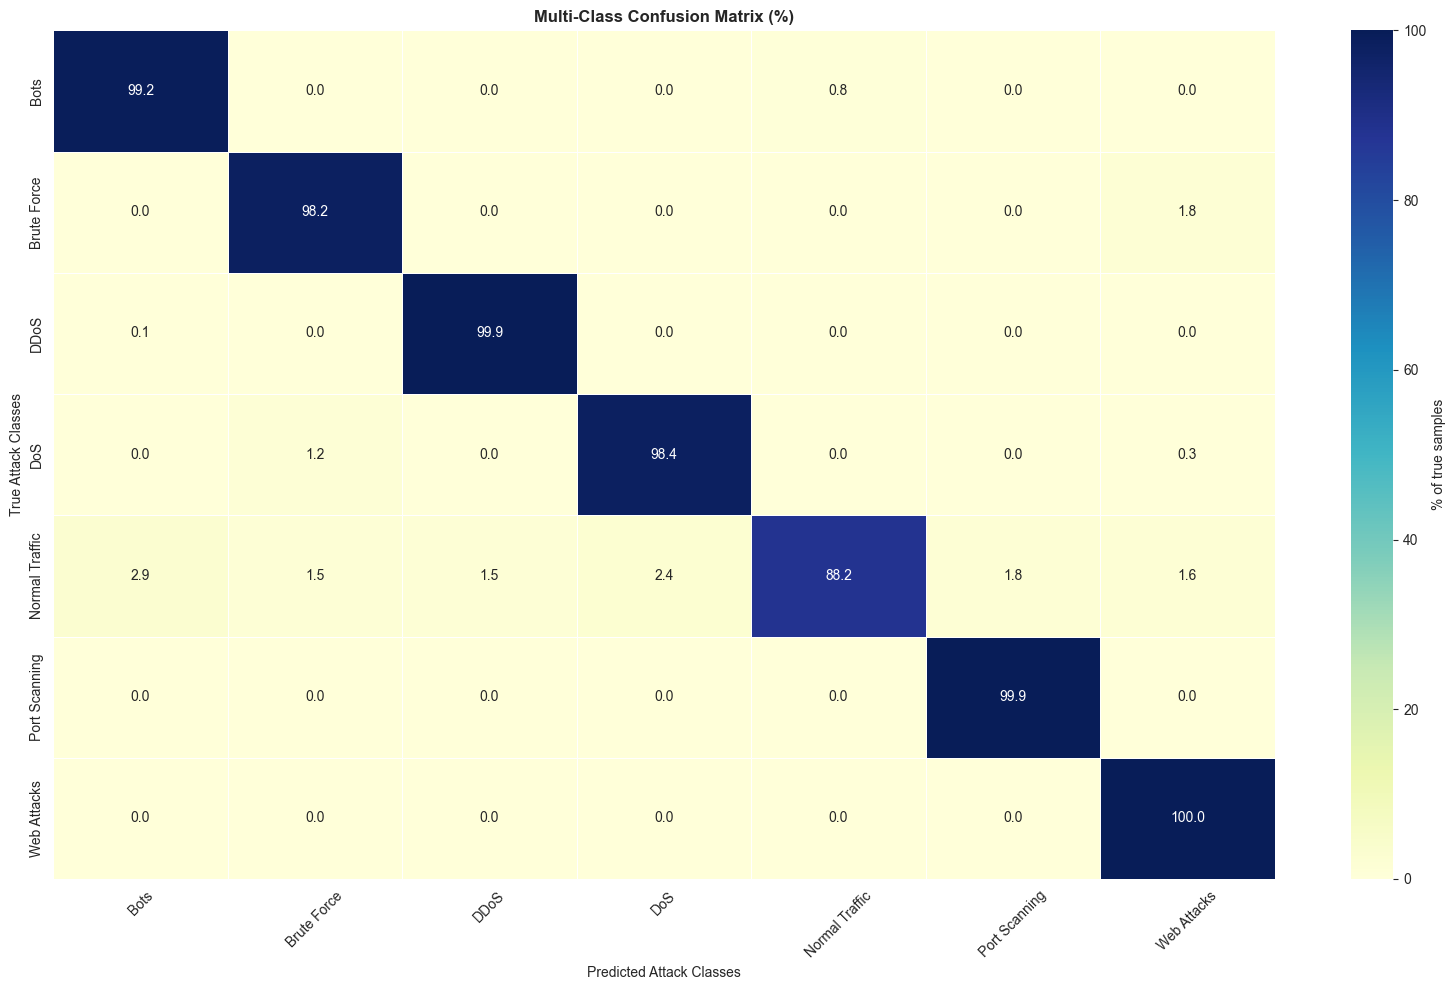

Per-class detection rate (Recall):
  Bots                     : 99.2%  (n=389)
  Brute Force              : 98.2%  (n=1,830)
  DDoS                     : 99.9%  (n=25,603)
  DoS                      : 98.4%  (n=38,749)
  Normal Traffic           : 88.2%  (n=419,012)
  Port Scanning            : 99.9%  (n=18,139)
  Web Attacks              : 100.0%  (n=429)


In [14]:
# 6.3 — Normalized Multi-Class Confusion Matrix Plot
true_labels = label_encoder.inverse_transform(y_test)
pred_labels = label_encoder.inverse_transform(y_pred)

# Build raw confusion crosstab
cm = pd.crosstab(
    pd.Series(true_labels, name='True Label'),
    pd.Series(pred_labels, name='Predicted Label')
)
cm = cm.reindex(index=CLASS_NAMES, columns=CLASS_NAMES, fill_value=0)

# Normalize by true label counts to get recall percentages per row
cm_pct = cm.div(cm.sum(axis=1), axis=0).fillna(0.0) * 100

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5, ax=ax,
            cbar_kws={'label': '% of true samples'})
ax.set_title('Multi-Class Confusion Matrix (%)', fontweight='bold')
ax.set_xlabel('Predicted Attack Classes')
ax.set_ylabel('True Attack Classes')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Per-class detection rate (Recall):')
for cls in CLASS_NAMES:
    total = cm.loc[cls].sum()
    correct = cm.loc[cls, cls]
    print(f'  {cls:25s}: {correct/total*100:.1f}%  (n={int(total):,})')

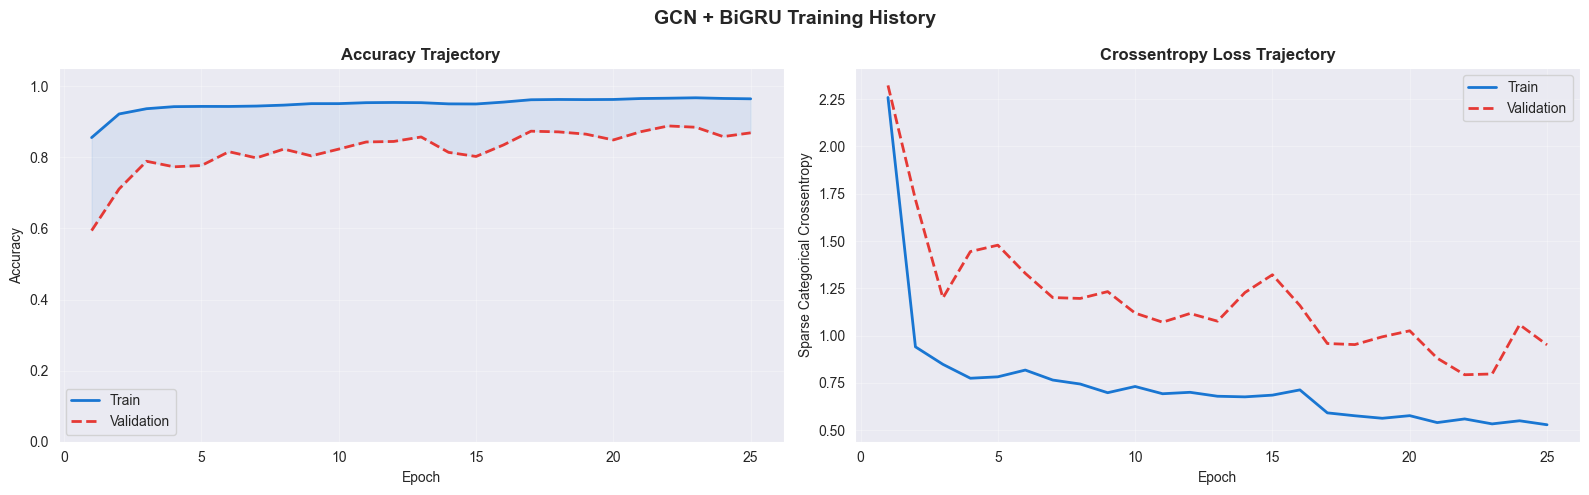

Saved history visualization to: ./dataset/cicids2017/epoch_curves.png


In [16]:
# 6.4 — Epoch-wise Training & Validation Metrics Plot
hist = getattr(h1, 'history', {})
if not hist:
    print('No training history found.')
else:
    epochs_ax = range(1, len(hist.get('accuracy', [])) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('GCN + BiGRU Training History', fontsize=14, fontweight='bold')

# Plot accuracy tracking over epochs
ax = axes[0]
ax.plot(epochs_ax, hist['accuracy'],     color='#1976D2', lw=2, label='Train')
ax.plot(epochs_ax, hist['val_accuracy'], color='#E53935', lw=2, linestyle='--', label='Validation')
ax.fill_between(epochs_ax, hist['accuracy'], hist['val_accuracy'], alpha=0.08, color='#1976D2')
ax.set_title('Accuracy Trajectory', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

# Plot Loss minimization over epochs
ax = axes[1]
ax.plot(epochs_ax, hist['loss'],     color='#1976D2', lw=2, label='Train')
ax.plot(epochs_ax, hist['val_loss'], color='#E53935', lw=2, linestyle='--', label='Validation')
ax.set_title('Crossentropy Loss Trajectory', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Sparse Categorical Crossentropy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./dataset/cicids2017/epoch_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved history visualization to: ./dataset/cicids2017/epoch_curves.png')